# Initial Momentum Scatter Plots — H_800_1e14 run

Uses the binned/refined initial-condition data produced by the `CQSFA_fwd` run with
`InputFiles/3D_Rel/H_800_1e14` (`runs/H_800_1e14/Data/`).

Note: the `3D_Rel` output format has **15** columns (it includes an extra out-of-plane
momentum/position component compared to the 12-column sample data used elsewhere in this
repo), so it's loaded directly with explicit column names.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

H800_DATA_DIR = "/workspaces/CQSFA/CQSFA_fwd/runs/H_800_1e14/Data"

# Column order matches initCondVars::printVars in CQSFA_fwd/src/initCondsGrid.cpp
COLUMNS = [
    "p0_z", "p0_perp", "p0_x",
    "t0_re", "t0_im", "z0",
    "pf_z", "pf_perp", "pf_x",
    "orbit",
    "rf_z", "rf_perp", "rf_x",
    "Vmax", "Rmin",
]

print("Loading to array....")
df = pd.DataFrame(
    np.loadtxt(f"{H800_DATA_DIR}/Binned_Initial_Condition_Grid_H_800_1e14_1000.dat"),
    columns=COLUMNS,
)
print(f"Loaded {len(df)} points, orbit counts:")
print(df["orbit"].value_counts().sort_index())
df.head()

Loading to array....
Loaded 83525 points, orbit counts:
orbit
1.0    23504
2.0    23368
3.0    25776
4.0    10877
Name: count, dtype: int64


,p0_z,p0_perp,p0_x,t0_re,t0_im,z0,pf_z,pf_perp,pf_x,orbit,rf_z,rf_perp,rf_x,Vmax,Rmin
0,0.007578,-1.136800,-1.038764e-15,82.665072,22.071662,14.808141,-0.050201,-1.094378,-1.000000e-15,2.0,34.745133,-304.422021,-2.781691e-13,1.136825,14.808141
1,0.012612,-1.137328,-1.039247e-15,27.704265,22.075814,-14.814191,0.070281,-1.094378,-1.000000e-15,2.0,7.638911,-364.741196,-3.332865e-13,1.137398,14.814191
2,-0.491119,-1.093001,-1.056922e-15,87.584857,22.322874,14.617091,-0.552209,-1.034137,-1.000000e-15,2.0,-102.626976,-283.013145,-2.736710e-13,1.204018,14.435647
3,0.009307,-1.117821,-1.040514e-15,82.647395,21.931268,14.596507,-0.050201,-1.074297,-1.000000e-15,2.0,34.562120,-298.982758,-2.783054e-13,1.117860,14.596507
4,-0.488792,-1.085255,-1.029442e-15,22.743957,22.262834,-14.530451,-0.431727,-1.054217,-1.000000e-15,1.0,-160.310915,-355.976255,-3.376689e-13,1.190251,14.530451


## Initial momentum, colored by orbit

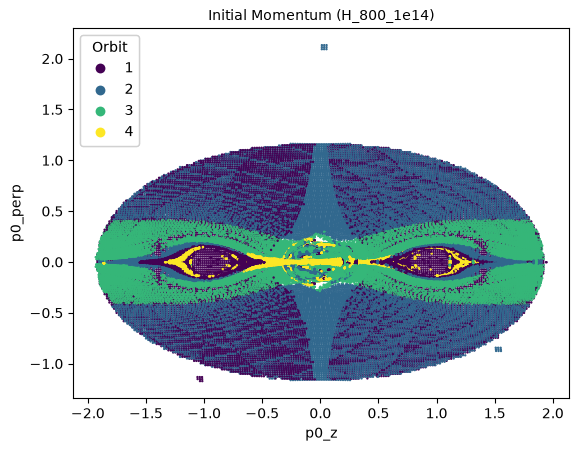

In [2]:
fig, ax = plt.subplots()
scatter = ax.scatter(df["p0_z"], df["p0_perp"], c=df["orbit"], s=0.5, cmap="viridis")
ax.set_title("Initial Momentum (H_800_1e14)", fontsize=10)
ax.set_xlabel("p0_z", fontsize=10)
ax.set_ylabel("p0_perp", fontsize=10)
legend1 = ax.legend(*scatter.legend_elements(), loc="upper left", title="Orbit")
ax.add_artist(legend1)
plt.show()

## Initial vs. final momentum, all orbits (array plot)

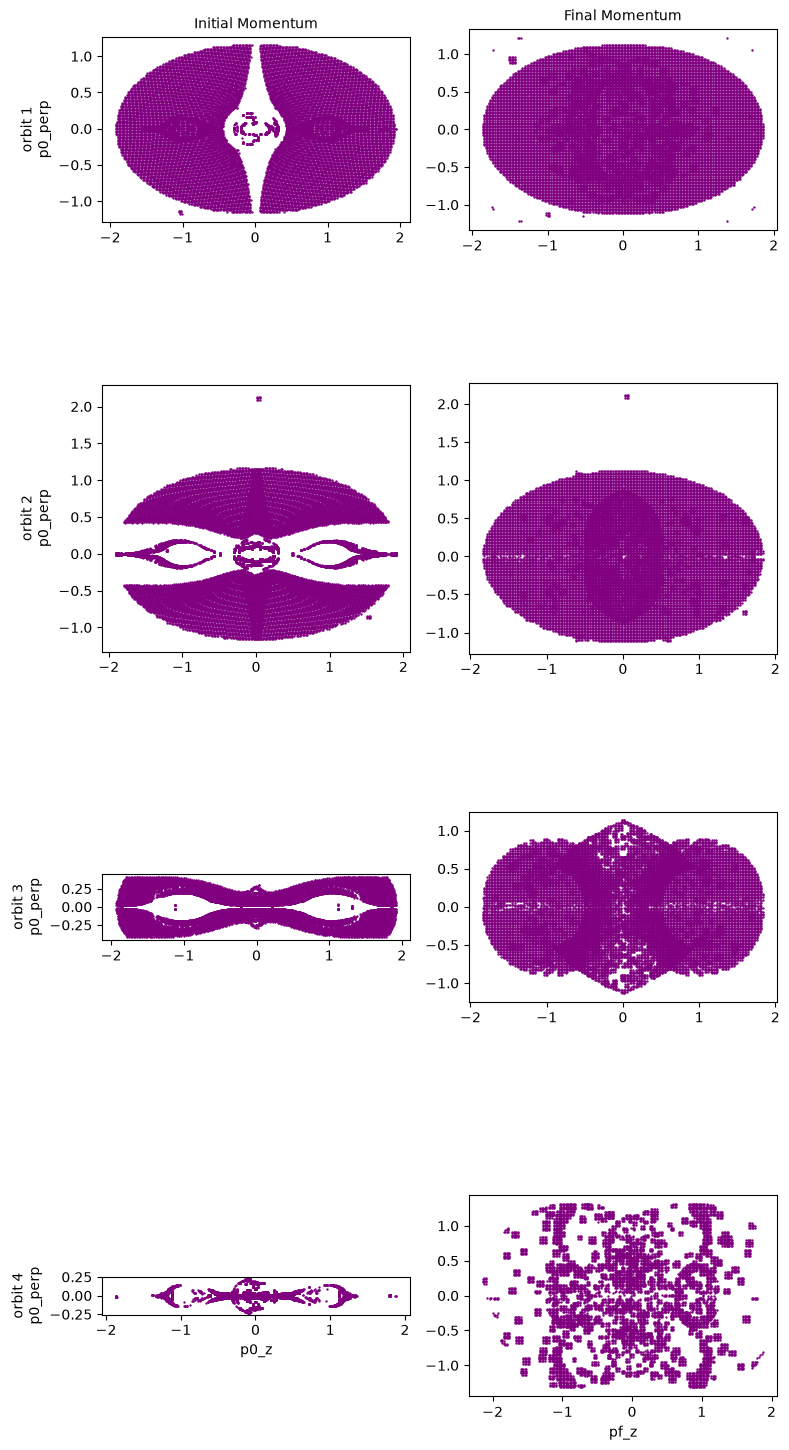

In [3]:
orbits = [1, 2, 3, 4]
fig, axes = plt.subplots(len(orbits), 2, figsize=(8, 4 * len(orbits)))

for row, orbit in enumerate(orbits):
    df_orbit = df[df["orbit"] == orbit]
    ax1, ax2 = axes[row]

    ax1.scatter(df_orbit["p0_z"], df_orbit["p0_perp"], s=0.5, color="purple")
    ax1.set(adjustable="box", aspect="equal")
    ax1.set_ylabel(f"orbit {orbit}\np0_perp", fontsize=10)
    if row == 0:
        ax1.set_title("Initial Momentum", fontsize=10)

    ax2.scatter(df_orbit["pf_z"], df_orbit["pf_perp"], s=0.5, color="purple")
    ax2.set(adjustable="box", aspect="equal")
    if row == 0:
        ax2.set_title("Final Momentum", fontsize=10)

axes[-1][0].set_xlabel("p0_z", fontsize=10)
axes[-1][1].set_xlabel("pf_z", fontsize=10)
plt.tight_layout()
plt.show()

## Orbit position vs time — which orbits rescatter with the core?

Uses `H_800_1e14_traj_export` (a small CQSFA_fwd run of the H_800_1e14 config, with
`exportIndexList` set to 48 final-momentum grid bins - 12 per orbit, stratified by radius
across each orbit's own coverage - so the sample isn't concentrated only near the centre).
Plotting $r(t)=\sqrt{r_z^2+r_\perp^2}$ shows directly whether a trajectory passes back close
to the parent ion (rescattering) or recedes monotonically. Orbit classification follows
`initCondsGrid::pointType()`, confirmed to match Table 1 of Maxwell et al., J. Phys. B 51,
124001 (2018).

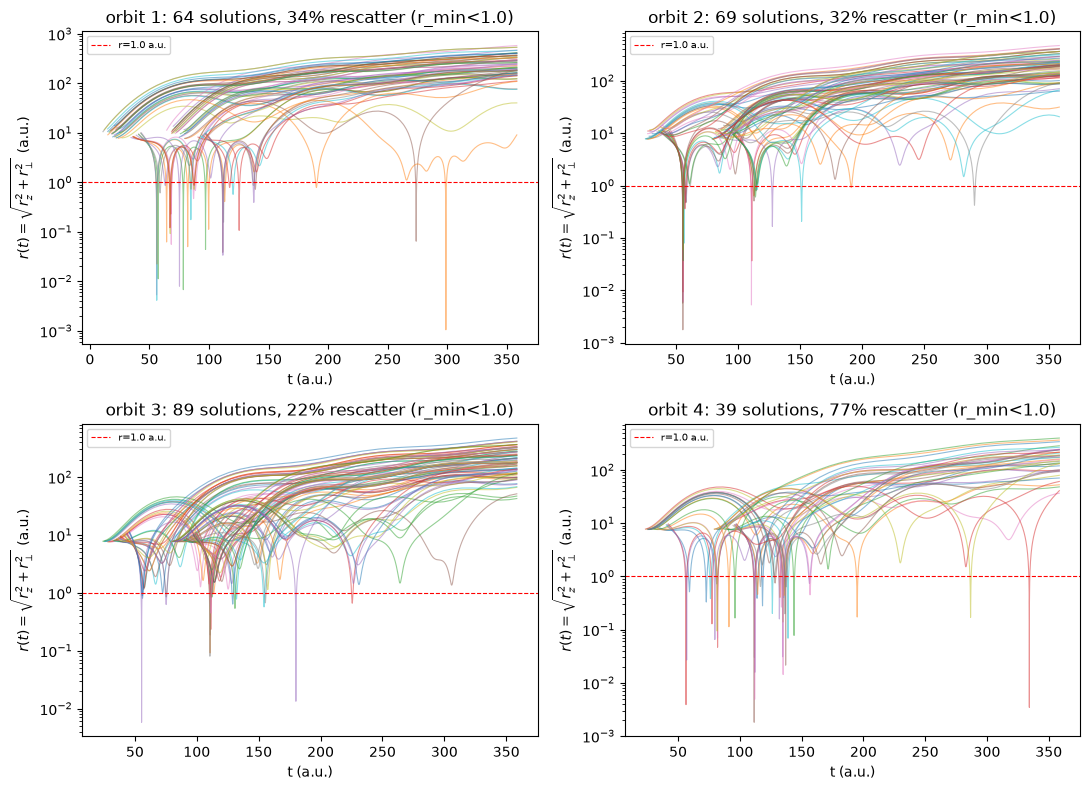

In [4]:
import glob

TRAJ_DIR = "/workspaces/CQSFA/CQSFA_fwd/runs/H_800_1e14_traj_export/Data"
CORE_THRESHOLD = 1.0  # a.u. - "close approach"/rescattering threshold

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for orb, ax in zip((1, 2, 3, 4), axes.flat):
    files = sorted(glob.glob(f"{TRAJ_DIR}/Path_Coords__*_orb_{orb}_sol_*.dat"))
    r_mins = []
    for fpath in files:
        d = np.loadtxt(fpath)
        if d.ndim != 2 or len(d) < 2:
            continue
        t, rz, rp = d[:, 0], d[:, 1], d[:, 2]
        r = np.hypot(rz, rp)
        r_mins.append(r.min())
        ax.plot(t, r, lw=0.8, alpha=0.5)
    ax.axhline(CORE_THRESHOLD, color="r", lw=0.8, ls="--", label=f"r={CORE_THRESHOLD} a.u.")
    ax.set_yscale("log")
    ax.set_xlabel("t (a.u.)")
    ax.set_ylabel(r"$r(t)=\sqrt{r_z^2+r_\perp^2}$ (a.u.)")
    r_mins = np.array(r_mins)
    frac_rescatter = (r_mins < CORE_THRESHOLD).mean() if len(r_mins) else float("nan")
    ax.set_title(f"orbit {orb}: {len(files)} solutions, {frac_rescatter:.0%} rescatter (r_min<{CORE_THRESHOLD})")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Same trajectories, but $r_z$ and $r_\perp$ plotted separately

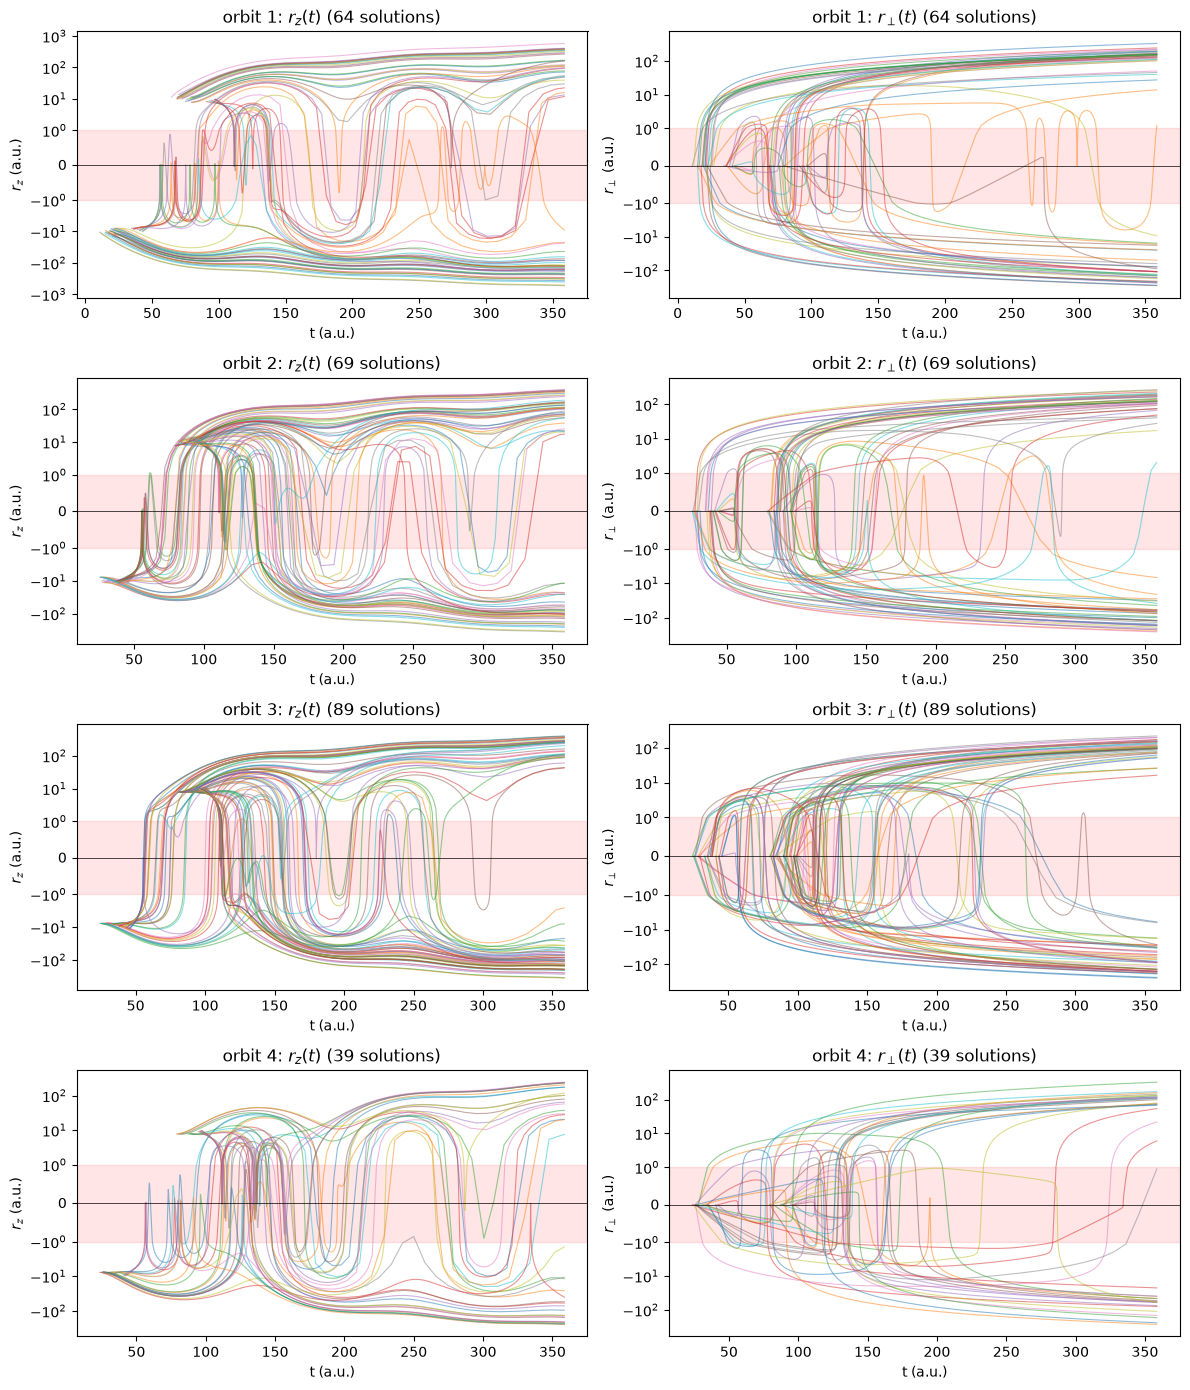

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharex=False)
for row, orb in enumerate((1, 2, 3, 4)):
    files = sorted(glob.glob(f"{TRAJ_DIR}/Path_Coords__*_orb_{orb}_sol_*.dat"))
    ax_z, ax_p = axes[row]
    for fpath in files:
        d = np.loadtxt(fpath)
        if d.ndim != 2 or len(d) < 2:
            continue
        t, rz, rp = d[:, 0], d[:, 1], d[:, 2]
        ax_z.plot(t, rz, lw=0.8, alpha=0.5)
        ax_p.plot(t, rp, lw=0.8, alpha=0.5)

    for ax, label in ((ax_z, r"$r_z$"), (ax_p, r"$r_\perp$")):
        ax.axhline(0, color="k", lw=0.5)
        ax.axhspan(-CORE_THRESHOLD, CORE_THRESHOLD, color="r", alpha=0.1)
        ax.set_yscale("symlog", linthresh=CORE_THRESHOLD)
        ax.set_xlabel("t (a.u.)")
        ax.set_ylabel(f"{label} (a.u.)")
    ax_z.set_title(f"orbit {orb}: $r_z(t)$ ({len(files)} solutions)")
    ax_p.set_title(f"orbit {orb}: $r_\\perp(t)$ ({len(files)} solutions)")
plt.tight_layout()
plt.show()